In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path="../data/"
constraints_dataset_url = data_path+"constants.xlsx"
c_columns_drop=["Unnamed: 0", "link"]
c_df = pd.read_excel(constraints_dataset_url).drop(columns=c_columns_drop).set_index("name")

In [3]:
####create dataset
#df=pd.DataFrame
data = []
step_size=0.05
for xa in np.arange(0, 1, step_size):
    for ya in np.arange(0, 1-xa, step_size):
        for xc in np.arange(0, 1, step_size):
            for yc in np.arange(0, 1-xc, step_size):
                data.append([xa, ya, 1-xa-ya, xc, yc, 1-xc-yc])
                #new_row = {'xA': xa, 'yA': ya, 'zA': 1-xa-ya, 'xC': xc, 'yC': yc, 'zC': 1-xc-yc}
                #df.loc[len(df)] = new_row
                #print([xa, ya, 1-xa-ya, xc, yc, 1-xc-yc])
df = pd.DataFrame(data)
df.columns = ["xA", "yA", "zA", "xC", "yC", "zC"]
df = df.round(2)

In [4]:
df["A1"]="Cs"
df["A2"]="MA"
df["A3"]="FA"
df["B"]="Pb"
df["C1"]="Cl"
df["C2"]="Br"
df["C3"]="I"

In [5]:
df

,xA,yA,zA,xC,yC,zC,A1,A2,A3,B,C1,C2,C3
0,0.00,0.0,1.00,0.00,0.00,1.00,Cs,MA,FA,Pb,Cl,Br,I
1,0.00,0.0,1.00,0.00,0.05,0.95,Cs,MA,FA,Pb,Cl,Br,I
2,0.00,0.0,1.00,0.00,0.10,0.90,Cs,MA,FA,Pb,Cl,Br,I
3,0.00,0.0,1.00,0.00,0.15,0.85,Cs,MA,FA,Pb,Cl,Br,I
4,0.00,0.0,1.00,0.00,0.20,0.80,Cs,MA,FA,Pb,Cl,Br,I
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44095,0.95,0.0,0.05,0.85,0.05,0.10,Cs,MA,FA,Pb,Cl,Br,I
44096,0.95,0.0,0.05,0.85,0.10,0.05,Cs,MA,FA,Pb,Cl,Br,I
44097,0.95,0.0,0.05,0.90,0.00,0.10,Cs,MA,FA,Pb,Cl,Br,I
44098,0.95,0.0,0.05,0.90,0.05,0.05,Cs,MA,FA,Pb,Cl,Br,I


In [6]:
###inserting element radii
def calculate_r_value(name):
  value = 0
  if name in c_df.columns:
    print("'"+name+"'")
    value = c_df.loc['r', name]
  return value

for col in ['rA1', 'rA2', 'rA3', 'rB', 'rC1', 'rC2', 'rC3']:
  df[col] = calculate_r_value(df.loc[0, col[1:]])

'Cs'
'MA'
'FA'
'Pb'
'Cl'
'Br'
'I'


In [7]:
###calculating radii of A and C
df["rA"] = df["xA"]*df["rA1"]+df["yA"]*df["rA2"]+df["zA"]*df["rA3"]
df["rC"] = df["xC"]*df["rC1"]+df["yC"]*df["rC2"]+df["zC"]*df["rC3"]
###calculating the composite columns
df["TF"]=(df["rA"]+df["rC"])/np.sqrt(2)/(df["rB"]+df["rC"])
df["OF"]=df["rB"]/df["rC"]

In [8]:
df.to_csv(data_path+"prepared_predict_Sona.csv")

In [9]:
df[(df["rC"]>2.08)&(df["rC"]<2.11)]["xC"].unique()

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 ])

In [10]:
df[(df["xC"]==0)&(df["rC"]>2.08)&(df["rC"]<2.11)]

,xA,yA,zA,xC,yC,zC,A1,A2,A3,B,...,rA2,rA3,rB,rC1,rC2,rC3,rA,rC,TF,OF
8,0.00,0.00,1.00,0.0,0.40,0.60,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,2.5300,2.104,0.994758,0.565589
9,0.00,0.00,1.00,0.0,0.45,0.55,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,2.5300,2.092,0.995810,0.568834
218,0.00,0.05,0.95,0.0,0.40,0.60,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,2.5115,2.104,0.990787,0.565589
219,0.00,0.05,0.95,0.0,0.45,0.55,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,2.5115,2.092,0.991824,0.568834
428,0.00,0.10,0.90,0.0,0.40,0.60,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,2.4930,2.104,0.986815,0.565589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43479,0.90,0.00,0.10,0.0,0.45,0.55,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,1.7560,2.092,0.829051,0.568834
43688,0.90,0.05,0.05,0.0,0.40,0.60,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,1.7375,2.104,0.824636,0.565589
43689,0.90,0.05,0.05,0.0,0.45,0.55,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,1.7375,2.092,0.825066,0.568834
43898,0.95,0.00,0.05,0.0,0.40,0.60,Cs,MA,FA,Pb,...,2.16,2.53,1.19,1.81,1.96,2.2,1.7130,2.104,0.819377,0.565589


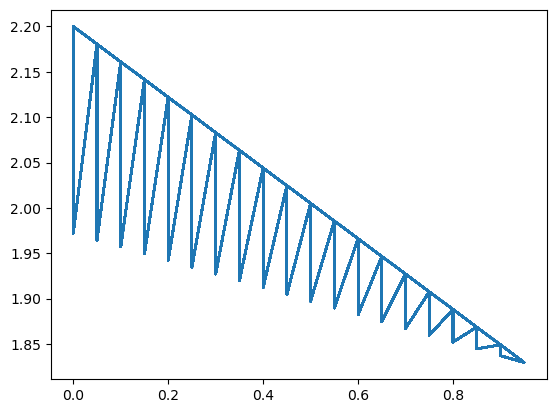

In [11]:
plt.plot(df["xC"], df["rC"])